Forward Elimination

In [2]:
pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 1.9 MB/s eta 0:00:00 MB/s eta 0:00:01:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
from mlxtend.feature_selection import SequentialFeatureSelector

In [6]:
data = pd.read_csv('diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
x = data.iloc[:, :-1]
y = data['Outcome']

In [10]:
from sklearn.linear_model import LogisticRegression

In [22]:
lr = LogisticRegression()
fs = SequentialFeatureSelector(lr, k_features = 5, forward = True)
fs.fit(x,y)

,estimator,LogisticRegression()
,k_features,"(5, ...)"
,forward,True
,floating,False
,verbose,0
,scoring,'accuracy'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [18]:
fs.feature_names
['Pregnancies','BloodPressure','SkinThickness','Age','Insulin']

['Pregnancies', 'BloodPressure', 'SkinThickness', 'Age', 'Insulin']

In [19]:
fs.k_feature_names_

('Pregnancies', 'Glucose', 'Insulin', 'BMI', 'Age')

In [21]:
fs.k_score_

0.7708768355827178

In [23]:
fs = SequentialFeatureSelector(lr, k_features = 4, forward = True)
fs.fit(x,y)
fs.feature_names
['Pregnancies','BloodPressure','SkinThickness','Age']

['Pregnancies', 'BloodPressure', 'SkinThickness', 'Age']

In [25]:
fs.k_feature_names_

('Glucose', 'Insulin', 'BMI', 'Age')

In [26]:
fs.k_score_

0.7682964094728801

In [27]:
fs = SequentialFeatureSelector(lr, k_features = 4, forward = False)
fs.fit(x,y)
fs.feature_names
['Pregnancies','BloodPressure','SkinThickness','Age']

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Plea

['Pregnancies', 'BloodPressure', 'SkinThickness', 'Age']

In [28]:
fs.k_feature_names_

('Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction')

In [29]:
fs.k_score_

0.7721330956625074

In [30]:
import pandas as pd

In [31]:
data = pd.read_csv('Boston.csv')

In [32]:
data.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [33]:
data.isnull().sum()

Unnamed: 0    0
crim          0
zn            0
indus         0
chas          0
nox           0
rm            0
age           0
dis           0
rad           0
tax           0
ptratio       0
black         0
lstat         0
medv          0
dtype: int64

In [35]:
input_data = data.iloc[:,:-1]
output_data = data['black']

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
x_train,x_test,y_train,y_test = train_test_split(input_data ,output_data ,test_size = 0.5)

In [39]:
x_train

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
98,99,0.08187,0.0,2.89,0,0.445,7.820,36.9,3.4952,2,276,18.0,393.53,3.57
306,307,0.07503,33.0,2.18,0,0.472,7.420,71.9,3.0992,7,222,18.4,396.90,6.47
468,469,15.57570,0.0,18.10,0,0.580,5.926,71.0,2.9084,24,666,20.2,368.74,18.13
405,406,67.92080,0.0,18.10,0,0.693,5.683,100.0,1.4254,24,666,20.2,384.97,22.98
336,337,0.03427,0.0,5.19,0,0.515,5.869,46.3,5.2311,5,224,20.2,396.90,9.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,150,2.73397,0.0,19.58,0,0.871,5.597,94.9,1.5257,5,403,14.7,351.85,21.45
310,311,2.63548,0.0,9.90,0,0.544,4.973,37.8,2.5194,4,304,18.4,350.45,12.64
424,425,8.79212,0.0,18.10,0,0.584,5.565,70.6,2.0635,24,666,20.2,3.65,17.16
339,340,0.05497,0.0,5.19,0,0.515,5.985,45.4,4.8122,5,224,20.2,396.90,9.74


In [41]:
y_test

113    396.90
220    391.70
388    372.92
408    314.64
444    240.52
        ...  
249    393.74
156     88.63
41     385.41
132    385.76
90     392.18
Name: black, Length: 253, dtype: float64

In [45]:
x_test.shape, x_train.shape

((253, 14), (253, 14))

In [46]:
y_train.shape, y_test.shape

((253,), (253,))

In [160]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [161]:
data = pd.read_csv('placement .csv')

In [163]:
data.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [164]:
data.isnull().sum()

cgpa       0
package    0
dtype: int64

In [165]:
data.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [166]:
x = data[['cgpa']]
y = data['package']

In [167]:
y.ndim

1

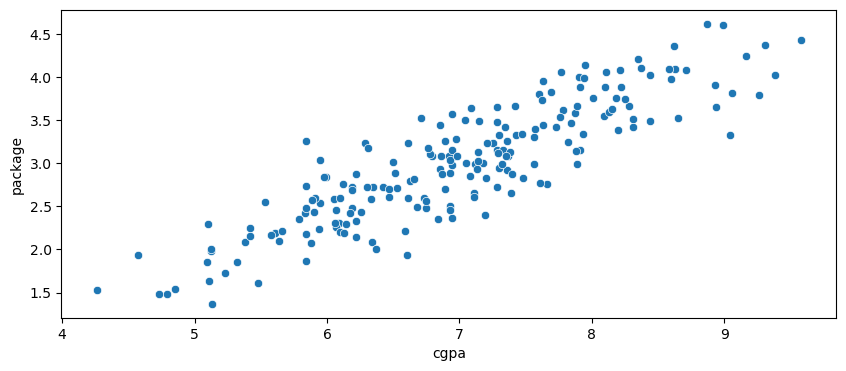

In [168]:
plt.figure(figsize = (10,4))
sns.scatterplot(x ='cgpa', y = 'package', data = data)
plt.show()

In [27]:
#x_train = data.iloc[:, 1:2]
#y_train = data.iloc[:, 1:2]

In [179]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)

In [180]:
slr = LinearRegression()
slr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [181]:
slr.score(x_train,y_train)

0.7828599385842709

In [90]:
#y = mx+c

In [182]:
slr.coef_

array([0.57018094])

In [183]:
slr.intercept_

-0.980883767663578

In [157]:
0.57018094*6.89-0.980883767663578

2.9476629089364215

In [184]:
slr.predict([[6.89]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.94766291])

In [185]:
y_slr = slr.predict(x)

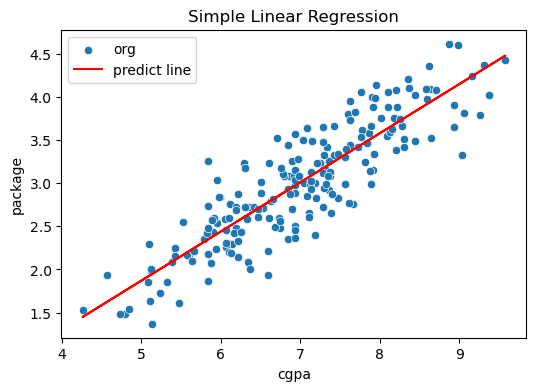

In [186]:
plt.figure(figsize = (6,4))
sns.scatterplot(x ='cgpa', y = 'package', data = data)
plt.plot(data['cgpa'],slr.predict(x), c = 'r')
plt.title('Simple Linear Regression')
plt.legend(['org', 'predict line'])
plt.savefig('predict.jpg')
plt.show()

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D

In [5]:
data = pd.read_csv('salary_predict.csv')

In [6]:
data.head()

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [7]:
data.shape

(20, 3)

In [8]:
data.isnull().sum()

age           0
experience    0
income        0
dtype: int64

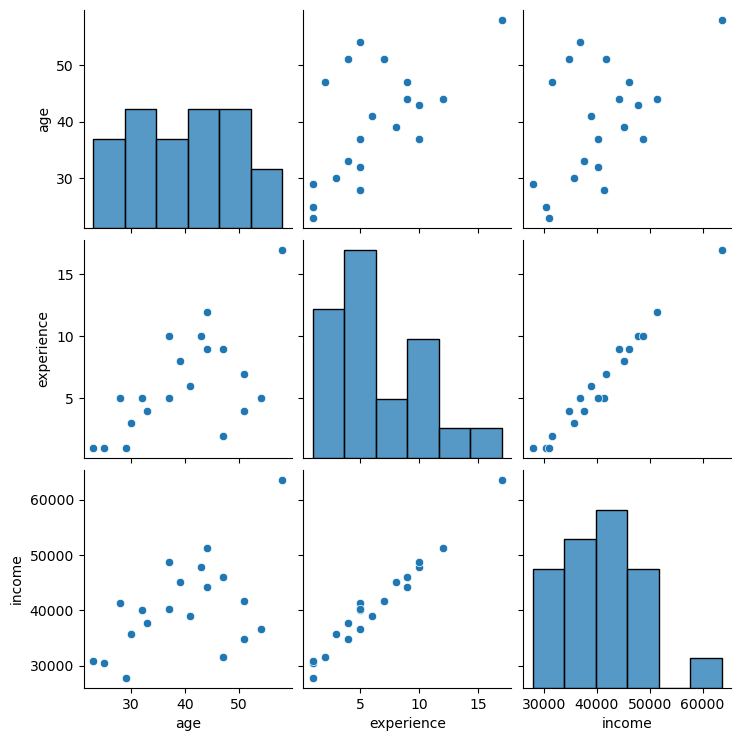

In [10]:
sns.pairplot(data = data)
plt.show()

In [11]:
x = data.iloc[:, :-1]
y = data['income']

In [12]:
x.ndim

2

In [13]:
data.shape

(20, 3)

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 39)

In [15]:
lr = LinearRegression()
lr.fit(x,data['income'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
lr.score(x,data['income'])*100

97.73361310180798

In [17]:
lr.coef_

array([ -99.19535546, 2162.40419192])

In [252]:
# y = m1x1 + m2x2 + c

In [18]:
lr.intercept_

31261.689854101285

In [19]:
lr.predict(x)

array([30944.2101595 , 34773.04176604, 30924.31653128, 38899.45943897,
       48620.33148852, 41339.55606906, 39296.24086081, 36637.85989158,
       38403.48266166, 44692.30452651, 30547.42873765, 46061.14587475,
       36717.16161882, 34852.34349328, 52845.9445169 , 40169.10543174,
       62269.23050007, 31142.60087042, 46358.73194113, 49215.50362128])

In [20]:
y_lr = lr.predict(x)

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


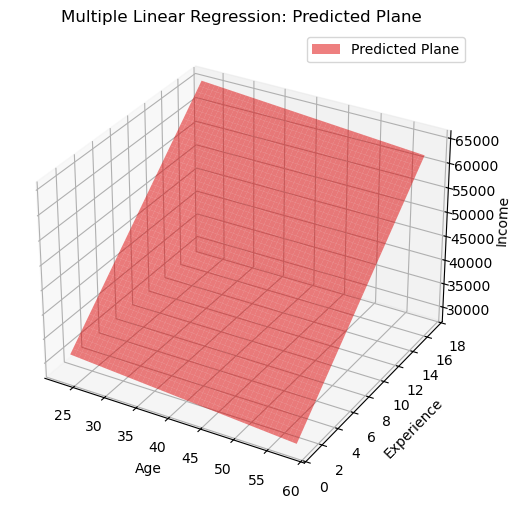

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D

data = pd.read_csv('salary_predict.csv')

x = data.iloc[:, :-1]
y = data['income']
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 39)

lr = LinearRegression()
lr.fit(x,data['income'])
y_lr = lr.predict(x)

age_range = np.linspace(data['age'].min(), data['age'].max(), 50)
exp_range = np.linspace(data['experience'].min(), data['experience'].max(), 50)
age_grid, exp_grid = np.meshgrid(age_range, exp_range)

ax.scatter(x['age'], x['experience'], y, color='blue', label='Actual Data')

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

age, exp = np.meshgrid(age_range, exp_range)
income_pred = lr.predict(np.c_[age_grid.ravel(), exp_grid.ravel()]).reshape(age_grid.shape)
ax.plot_surface(age_grid, exp_grid, income_pred, color='red', alpha=0.5, label='Predicted Plane')

ax.set_xlabel('Age')
ax.set_ylabel('Experience')
ax.set_zlabel('Income')
ax.set_title('Multiple Linear Regression: Predicted Plane')
ax.legend()

plt.show()

In [1]:
#Polynomial regression

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [26]:
data = pd.read_csv('Position_Salaries.csv')

In [29]:
data.drop(columns = ['Position'], inplace = True)

In [30]:
data.head()

,Level,Salary
0,1,45000
1,2,50000
2,3,60000
3,4,80000
4,5,110000


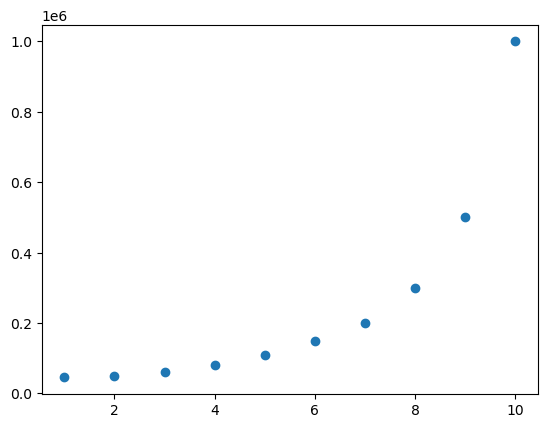

In [31]:
plt.scatter(data['Level'], data['Salary'])
plt.show()

In [81]:
x = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 39)

In [84]:
lr = LinearRegression()
lr.fit(x_train,y_train)
y_lr = lr.predict(x)

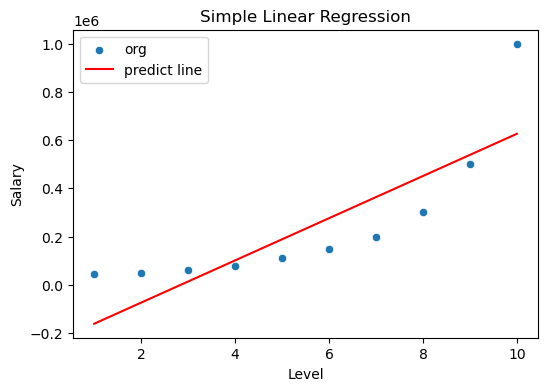

In [85]:
plt.figure(figsize = (6,4))
sns.scatterplot(x ='Level', y = 'Salary', data = data)
plt.plot(data['Level'],lr.predict(x), c = 'r')
plt.title('Simple Linear Regression')
plt.legend(['org', 'predict line'])
plt.show()

In [80]:
pf = PolynomialFeatures(degree=4)
y_pf_train = pf.fit_transform(x_train,y_train)
y_pf = pf.transform(x)

lr = LinearRegression()
lr.fit(y_pf_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


/tmp/ipykernel_3738/3806939232.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


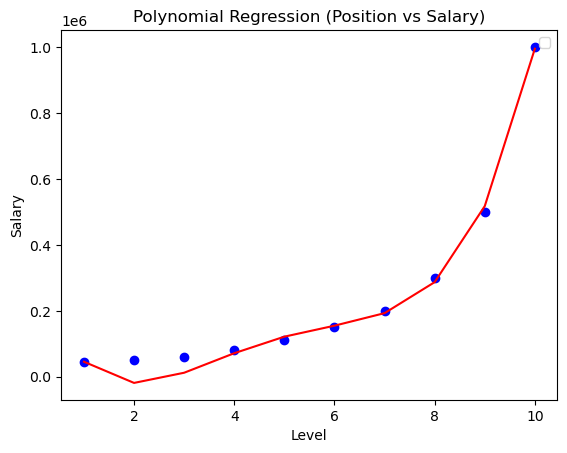

In [83]:
plt.scatter(x, y, color='blue')
plt.plot(x, lr.predict(y_pf), color='red')

plt.title('Polynomial Regression (Position vs Salary)')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [90]:
dataset = pd.read_csv('Ice_cream selling data.csv')
dataset.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [93]:
x = dataset[['Temperature (°C)']]  
y = dataset['Ice Cream Sales (units)']  

In [139]:
polyf = PolynomialFeatures()
x_poly = polyf.fit_transform(x_train,y_train)
p = polyf.transform(x)

In [137]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size= 0.1 ,random_state = 32)

In [152]:
lr = LinearRegression()
lr.fit(x_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [143]:
ployd = lr.predict(p)

/tmp/ipykernel_3738/3697505826.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


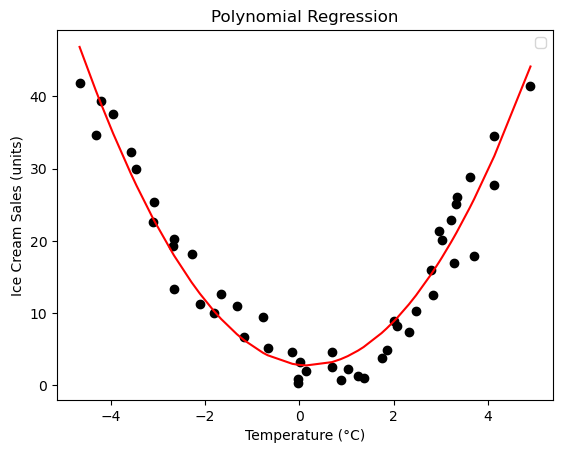

In [154]:
plt.scatter(x,y, color = 'black')
plt.plot(x,lr.predict(p),color= 'red' )

plt.title('Polynomial Regression')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.legend()
plt.show()

In [155]:
test = polyf.transform([[-3.949661]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [156]:
lr.predict(test)

array([34.86774413])

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
housing = pd.read_csv('house.csv')

In [3]:
housing.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [5]:
housing.drop(['street','city','statezip','country','date'],axis = 1, inplace = True)

In [6]:
housing.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992


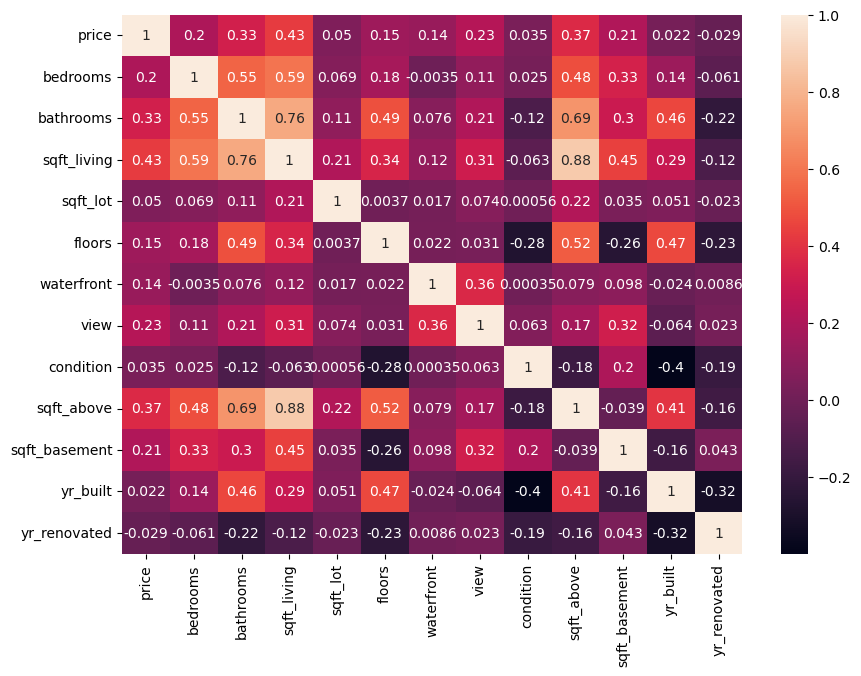

In [7]:
plt.figure(figsize = (10,7))
sns.heatmap(data = housing.corr(), annot = True)
plt.savefig('heat.jpg')
plt.show()

In [76]:
x = housing.iloc[:,:-1]
y = housing['price']

In [96]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 39)

In [97]:
sc = StandardScaler()
sc.fit(x)

,copy,True
,with_mean,True
,with_std,True


In [98]:
df = sc.transform(x)

In [99]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [100]:
lr.score(x_train, y_train)*100

100.0

In [82]:
lr.coef_

array([ 1.00000000e+00, -1.97409720e-11,  3.75722358e-11, -8.09588330e-14,
        2.91598563e-16,  3.22047693e-11,  9.34587827e-10, -4.10232164e-11,
        3.50958206e-12, -3.43239268e-14, -4.66348041e-14, -6.14140957e-13])

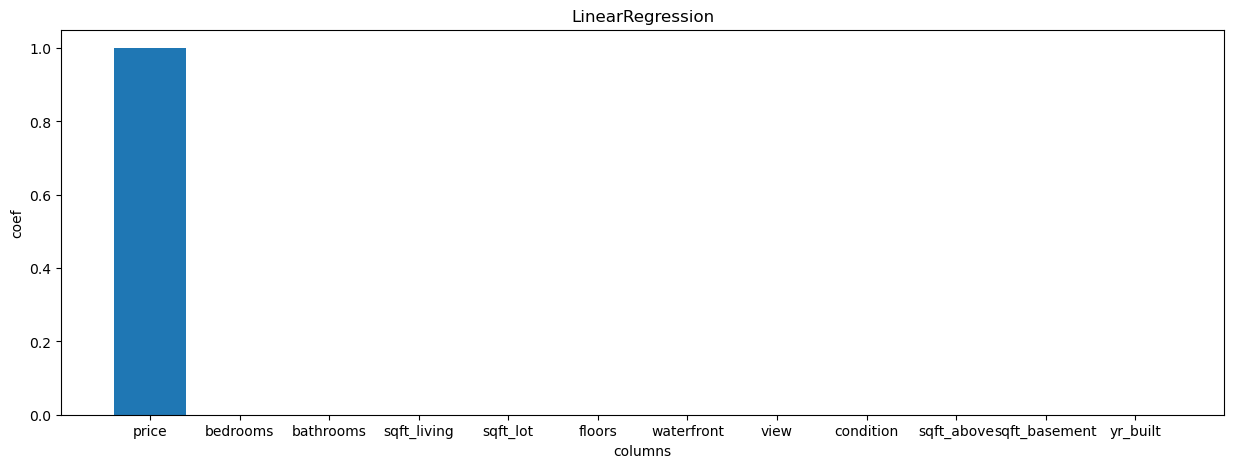

In [83]:
plt.figure(figsize = (15,5))
plt.bar(x.columns, lr.coef_)
plt.title('LinearRegression')
plt.xlabel('columns')
plt.ylabel('coef')
plt.show()

In [108]:
print(mean_squared_error(y_test, lr.predict(x_test)))
print(mean_absolute_error(y_test, lr.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, lr.predict(x_test))))

6.267540316984908e-19
3.7924963905698206e-10
7.916779848514741e-10


Lasso

In [63]:
la = Lasso(alpha = 0.5)
la.fit(x_train, y_train)
la.score(x_train, y_train)*100

100.0

In [64]:
la.coef_

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

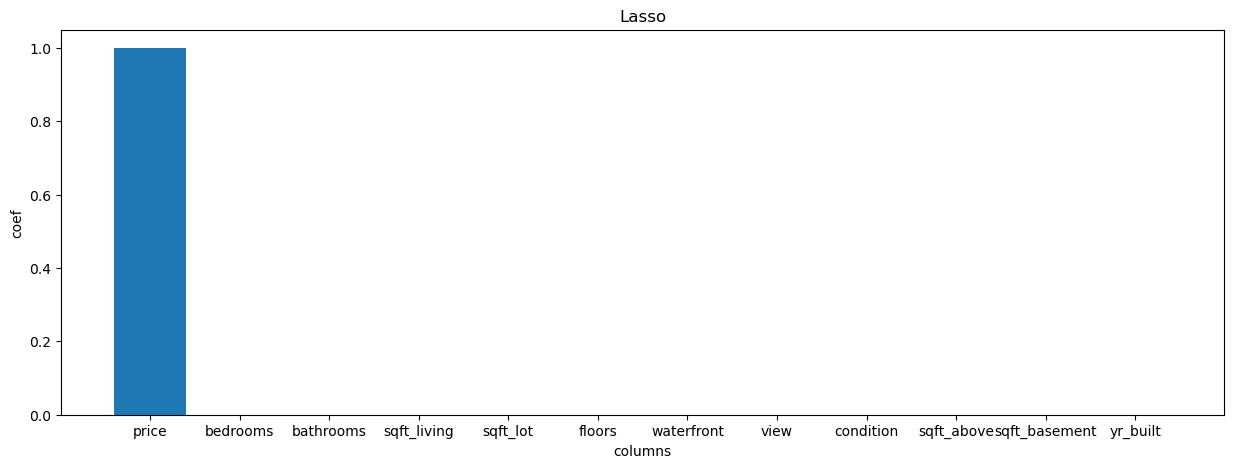

In [66]:
plt.figure(figsize = (15,5))
plt.bar(x.columns, la.coef_)
plt.title('Lasso')
plt.xlabel('columns')
plt.ylabel('coef')
plt.show()

In [107]:
print(mean_squared_error(y_test, la.predict(x_test)))
print(mean_absolute_error(y_test, la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, la.predict(x_test))))

4.663551710297978e-13
3.4508601580139087e-07
6.829020215446706e-07


Ridge

In [84]:
ri = Ridge(alpha = 0.5)
ri.fit(x_train, y_train)
ri.score(x_train, y_train)*100

100.0

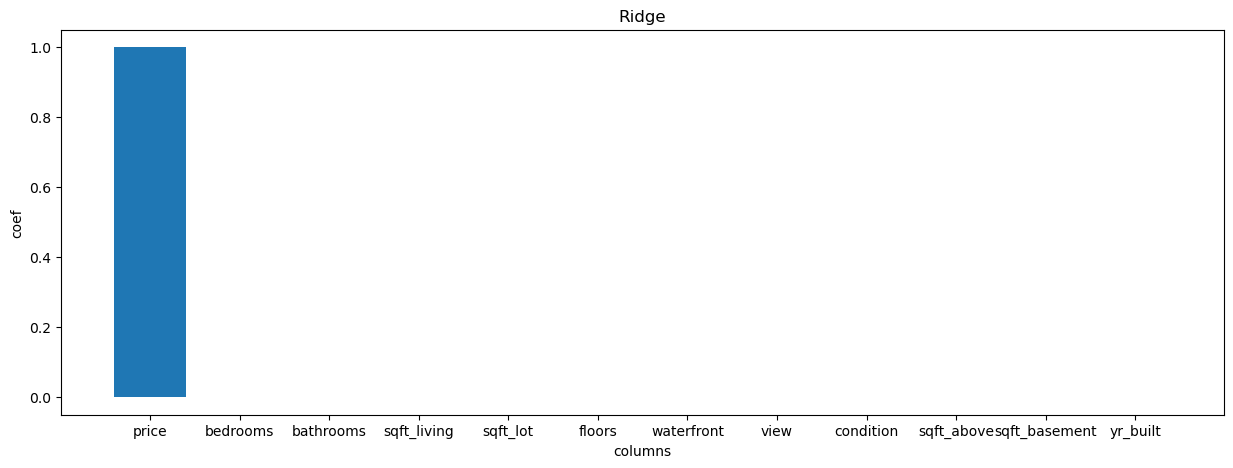

In [86]:
plt.figure(figsize = (15,5))
plt.bar(x.columns, ri.coef_)
plt.title('Ridge')
plt.xlabel('columns')
plt.ylabel('coef')
plt.show()

In [109]:
print(mean_squared_error(y_test, ri.predict(x_test)))
print(mean_absolute_error(y_test, ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, ri.predict(x_test))))

1.3279589634054726e-19
2.4759663435858384e-10
3.6441171268298617e-10


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
sco = pd.read_csv('Social_Network_Ads.csv')

In [3]:
sco.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
sco.drop(['User ID','Gender','EstimatedSalary'], axis = 1, inplace = True)

In [8]:
sco.head()

,Age,Purchased
0,19,0
1,35,0
2,26,0
3,27,0
4,19,0


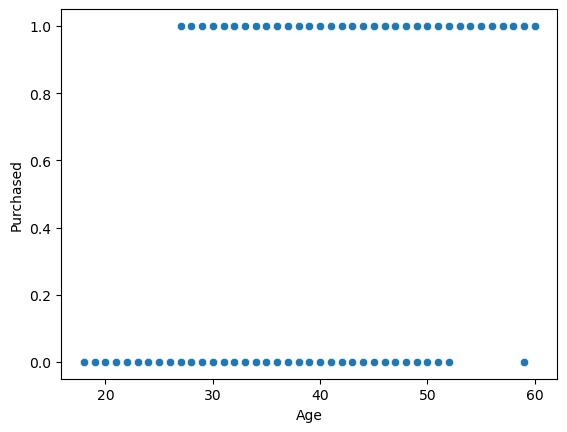

In [9]:
sns.scatterplot(x = 'Age', y = 'Purchased', data = sco)
plt.show()

In [10]:
x = sco[['Age']]
y = sco['Purchased']

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 39)

In [15]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
lr.score(x_train,y_train)*100

84.28571428571429

In [26]:
lr.predict([[60]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

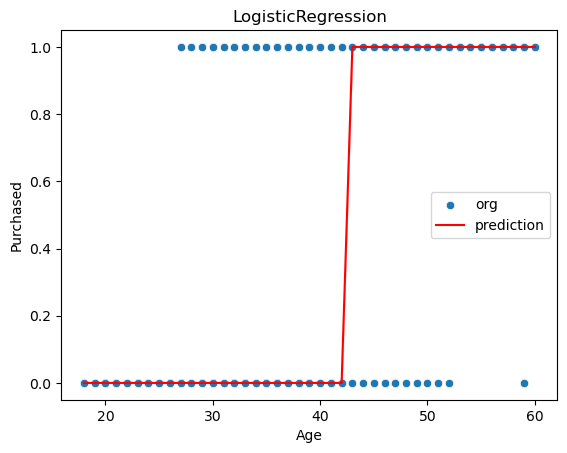

In [30]:
sns.scatterplot(x = 'Age', y = 'Purchased', data = sco)
sns.lineplot(x = 'Age', y = lr.predict(x), data = sco, color= 'red')
plt.title('LogisticRegression')
plt.legend(['org','prediction'])
plt.show()

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [34]:
daa = pd.read_csv('Social_Network_Ads.csv')

In [35]:
daa.drop(['User ID','Gender'], axis = 1, inplace = True)

In [36]:
daa.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


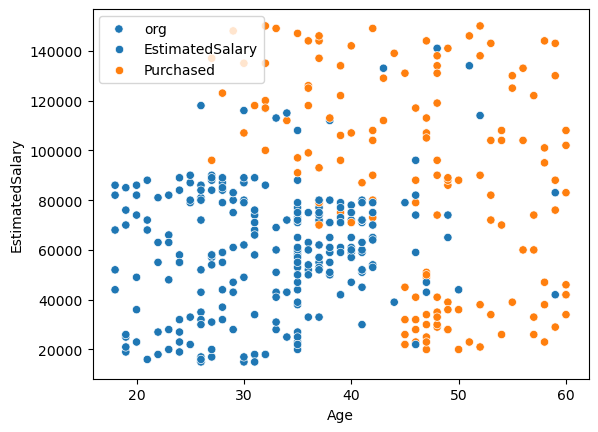

In [77]:
sns.scatterplot(x = 'Age', y = 'EstimatedSalary', data = sco, hue = 'Purchased')
plt.legend(['org','EstimatedSalary','Purchased'])
plt.show()

In [47]:
x = daa.iloc[:,:-1]
y = daa['Purchased']

In [71]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 36)

In [67]:
lrn = LogisticRegression()
lrn.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [72]:
lrn.score(x_train,y_train)*100

84.28571428571429

In [73]:
lr.predict([[60]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [74]:
pip install mlxtend  

Note: you may need to restart the kernel to use updated packages.


In [57]:
from mlxtend.plotting import plot_decision_regions

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


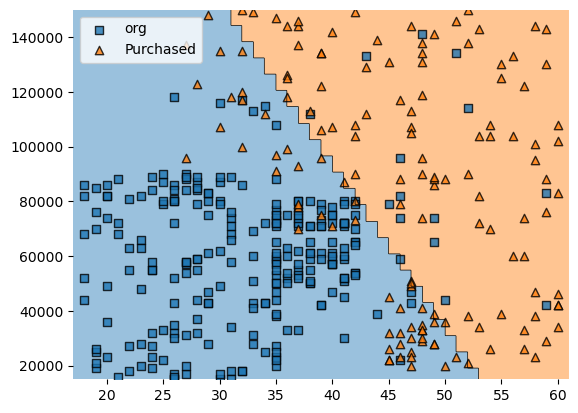

In [79]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf =lrn)
plt.legend(['org','Purchased'])
plt.show()

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [7]:
data = pd.read_csv('nonlinear_data_circles.csv')

In [8]:
data.head()

,x1,x2,label
0,0.160594,0.482602,1
1,1.198440,-0.542104,0
2,-0.618907,0.728517,0
3,1.070839,-0.340617,0
4,0.843196,-0.502865,0


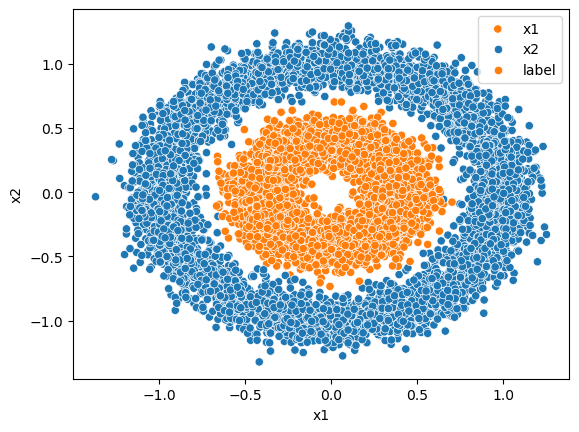

In [9]:
sns.scatterplot(x = 'x1', y = 'x2', data = data, hue = 'label')
plt.legend(['x1','x2','label'])
plt.show()

In [10]:
x = data.iloc[:,:-1]
y = data['label']

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 39)

In [12]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
lr.score(x_train,y_train)*100

51.5625

In [14]:
from mlxtend.plotting import plot_decision_regions

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


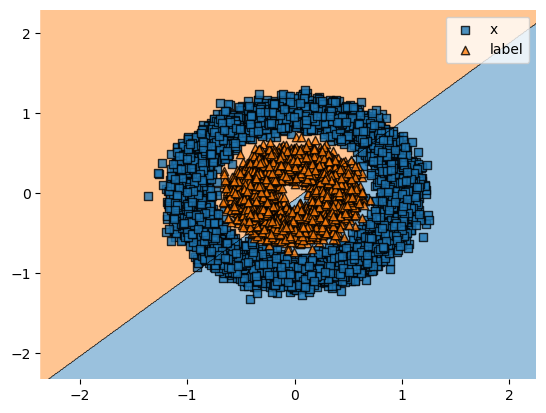

In [15]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf =lr)
plt.legend(['x','label'])
plt.show()

In [16]:
from sklearn.preprocessing import PolynomialFeatures

In [17]:
pf = PolynomialFeatures(degree = 2)
pf.fit(x)
x = pd.DataFrame(pf.transform(x))

In [18]:
lr.score(x_train,y_train)*100

51.5625

In [19]:
x.shape

(10000, 6)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [11]:
data = pd.read_csv('Iris.csv')

In [12]:
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
#data.drop(['Species'],axis = 1, inplace = True)

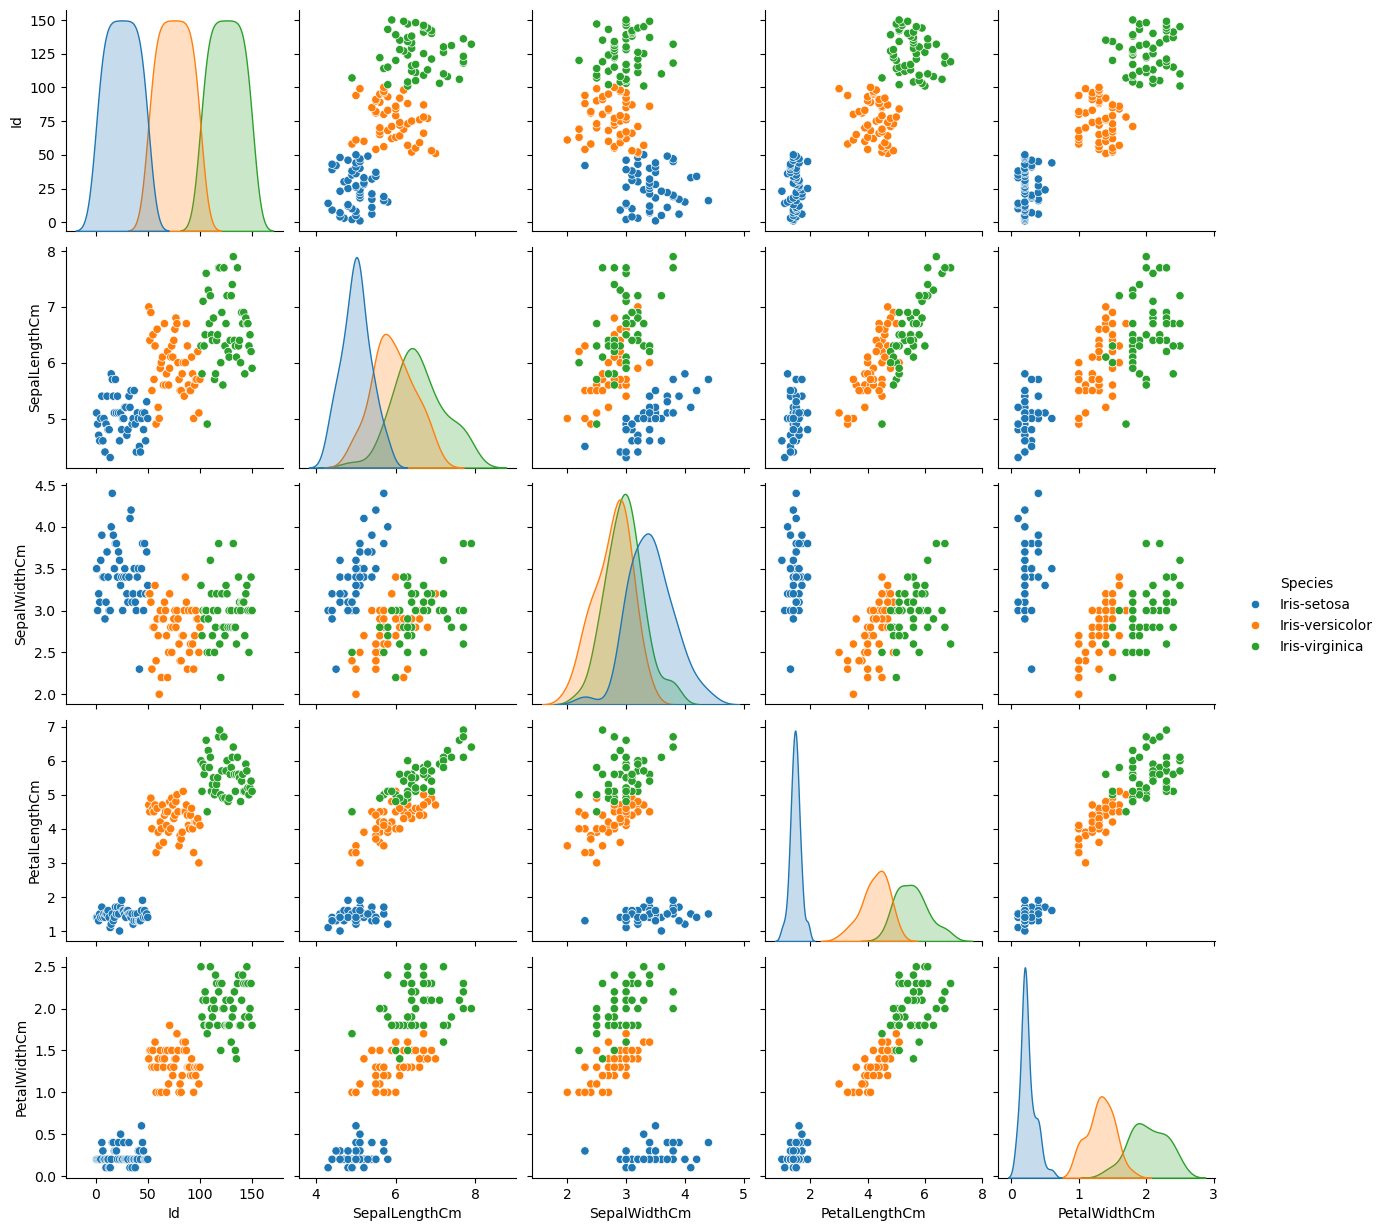

In [14]:
sns.pairplot(data = data, hue = 'Species')
plt.show()

In [15]:
x = data.iloc[:,:-1]
y = data['Species']

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 39)

OVR

In [19]:
lr = LogisticRegression(multi_class = 'ovr')
lr.fit(x_train,y_train)

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'ovr'


In [20]:
lr.score(x_train,y_train)*100

100.0

In [21]:
#Multinomial

In [22]:
lr = LogisticRegression(multi_class = 'multinomial')
lr.fit(x_train,y_train)

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [23]:
lr.score(x_train,y_train)*100

100.0

In [120]:
#confusion_matrix

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [26]:
data = pd.read_csv('placement (2).csv')

In [27]:
data.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [29]:
x = data.iloc[:,:-1]
y = data['placement']

In [113]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.1, random_state = 39)

In [37]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [114]:
lr.score(x_train,y_train)*100

94.44444444444444

In [115]:
confusion_matrix(y_test,lr.predict(x_test))

array([[1, 1],
       [1, 7]])

In [116]:
cf = confusion_matrix(y_test,lr.predict(x_test))

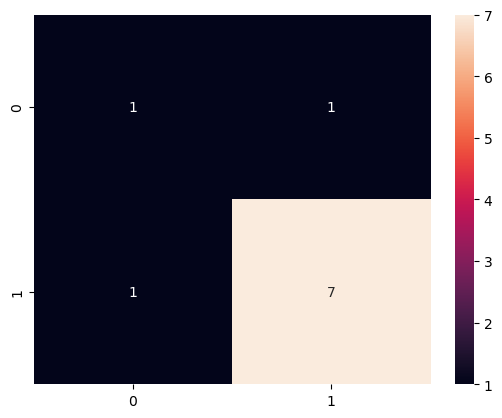

In [117]:
sns.heatmap(cf, annot =True)
plt.show()

In [118]:
precision_score(y_test,lr.predict(x_test))*100

87.5

In [52]:
recall_score(y_test,lr.predict(x_test))*100

87.5

In [119]:
f1_score(y_test,lr.predict(x_test))*100

87.5

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [4]:
data = pd.read_csv('Social_Network_Ads.csv')

In [36]:
data.head(20)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
5,27,58000,0
6,27,84000,0
7,32,150000,1
8,25,33000,0
9,35,65000,0


In [28]:
data.drop(['User ID'], axis = 1, inplace = True)

In [30]:
data.value_counts('Purchased')

Purchased
0    257
1    143
Name: count, dtype: int64

In [31]:
x = data.iloc[:,:-1]
y = data['Purchased']

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 39)

In [33]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [34]:
lr.score(x_test,y_test)*100

87.5

In [40]:
lr.predict([[19, 19000]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [39]:
lr.predict([[45,26000]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [42]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


imbalanced-learn

In [44]:
from imblearn.under_sampling import RandomUnderSampler

In [47]:
rus = RandomUnderSampler()
rus_x, rus_y = rus.fit_resample(x,y)

In [50]:
rus_y.value_counts()

Purchased
0    143
1    143
Name: count, dtype: int64

In [52]:
x_train, x_test, y_train, y_test = train_test_split(rus_x, rus_y, test_size = 0.2, random_state = 39)

In [66]:
lr =LogisticRegression()
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [67]:
lr.score(x_test,y_test)*100

86.20689655172413

In [69]:
lr.predict([[46, 28000]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [51]:
from imblearn.over_sampling import RandomOverSampler

In [72]:
rus = RandomOverSampler()
rus_x, rus_y = rus.fit_resample(x,y)

In [ ]:
lr =LogisticRegression()
lr.fit(x_train,y_train)

In [73]:
rus_y.value_counts()

Purchased
0    257
1    257
Name: count, dtype: int64

In [74]:
x_train, x_test, y_train, y_test = train_test_split(rus_x, rus_y, test_size = 0.2, random_state = 39)

In [75]:
lr =LogisticRegression()
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [76]:
lr.score(x_test,y_test)*100

80.58252427184466

In [77]:
lr.predict([[46, 28000]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [2]:
qua = pd.read_csv('placement (2).csv')

In [7]:
qua.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


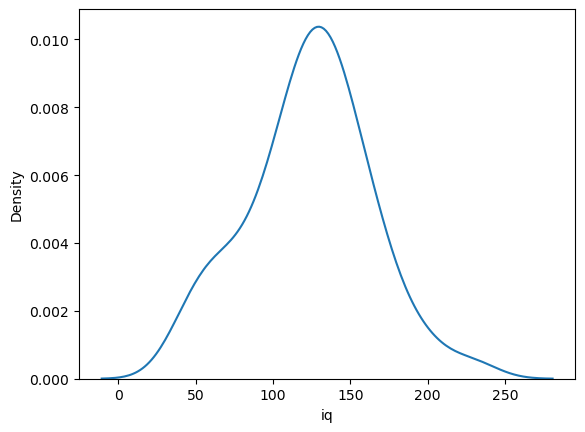

In [16]:
#sns.kdeplot(data = qua['iq'])
#plt.show()

In [6]:
qua.drop(['Unnamed: 0'], axis = 1, inplace = True)

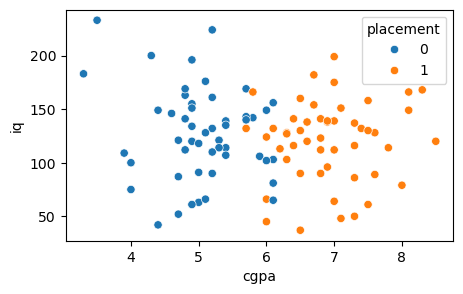

In [10]:
plt.figure(figsize = (5,3))
sns.scatterplot(x = 'cgpa', y = 'iq',data = qua, hue = 'placement')
plt.show()

In [11]:
x = qua.iloc[:,:-1]
y = qua['placement']

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state = 39)

In [18]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB,BernoulliNB

In [20]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [24]:
gnb.score(x_test, y_test)*100,gnb.score(x_train, y_train)*100

(90.0, 92.85714285714286)

In [42]:
gnb.predict([[6.8,123.0]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([1])

In [27]:
mnb = MultinomialNB()
mnb.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [28]:
mnb.score(x_test, y_test)*100,mnb.score(x_train, y_train)*100

(46.666666666666664, 68.57142857142857)

In [43]:
mnb.predict([[5.9,106.0]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


array([0])

In [30]:
bnb = BernoulliNB()
bnb.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [31]:
bnb.score(x_test, y_test)*100,bnb.score(x_train, y_train)*100

(36.666666666666664, 55.714285714285715)

In [45]:
bnb.predict([[7.4,132.0]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


array([0])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


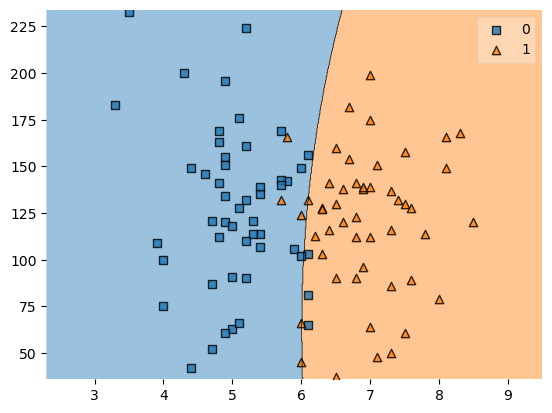

In [46]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf = gnb)
plt.show()

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


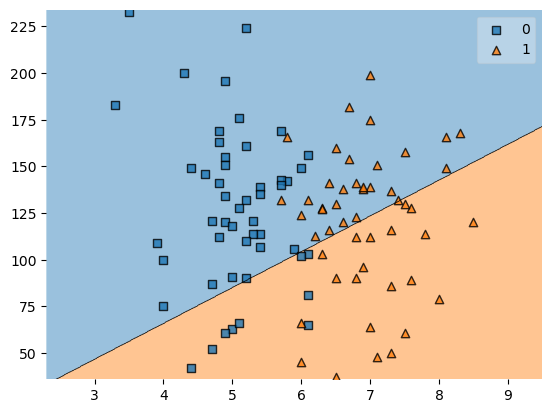

In [33]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf = mnb)
plt.show()

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


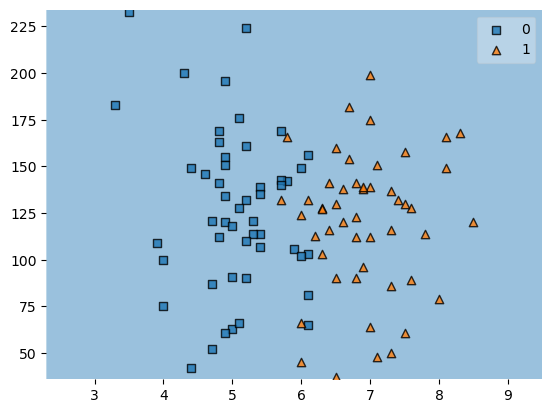

In [34]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf = bnb)
plt.show()

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

In [19]:
ds = pd.read_csv('placement (2).csv')

In [22]:
ds.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [21]:
ds.drop(['Unnamed: 0'], axis = 1, inplace = True)

<Figure size 2000x500 with 0 Axes>

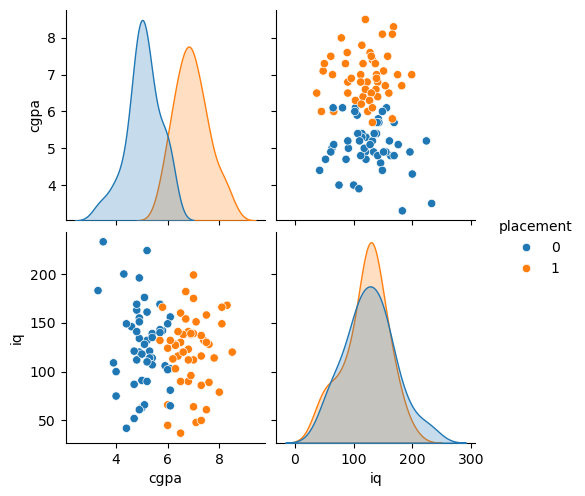

In [23]:
plt.figure(figsize = (20,5))
sns.pairplot(data = ds, hue = 'placement')
plt.show()

In [24]:
x = ds.iloc[:, :-1]
y = ds['placement']

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 39)

In [44]:
dts = DecisionTreeClassifier(max_depth = 5) #Pre Puring 
dts.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [36]:
dts1 = DecisionTreeClassifier(criterion = 'entropy')
dts1.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
dts.score(x_test, y_test)*100

90.0

In [37]:
dts1.score(x_test, y_test)*100

90.0

In [27]:
dts.predict([[6.8,123.0]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [38]:
dts1.predict([[6.8,123.0]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [31]:
from sklearn.tree import plot_tree

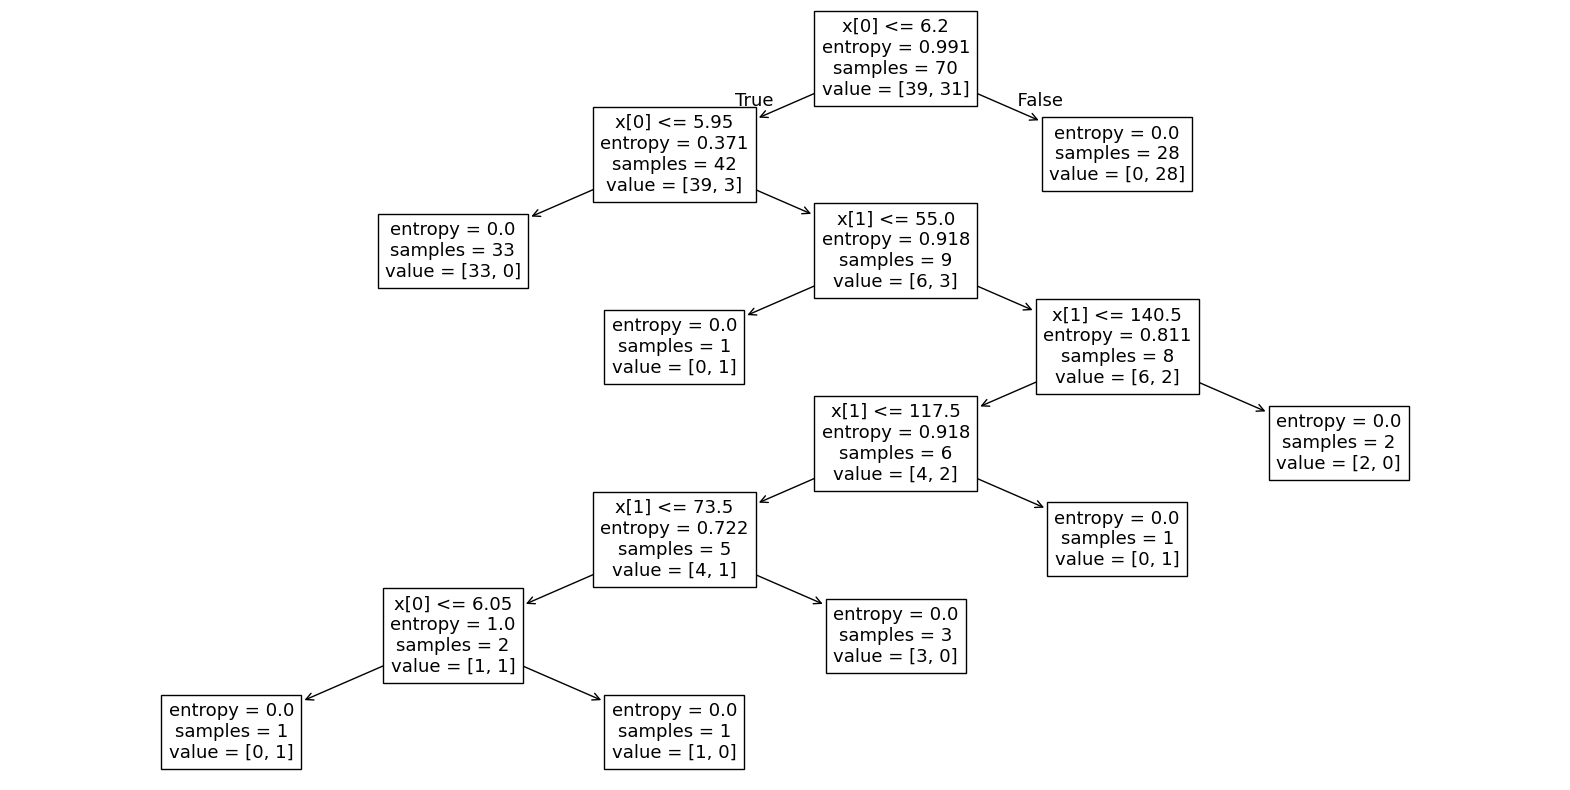

In [41]:
plt.figure(figsize = (20,10))
plot_tree(dts)
plt.savefig('tree.jpg')
plt.show()

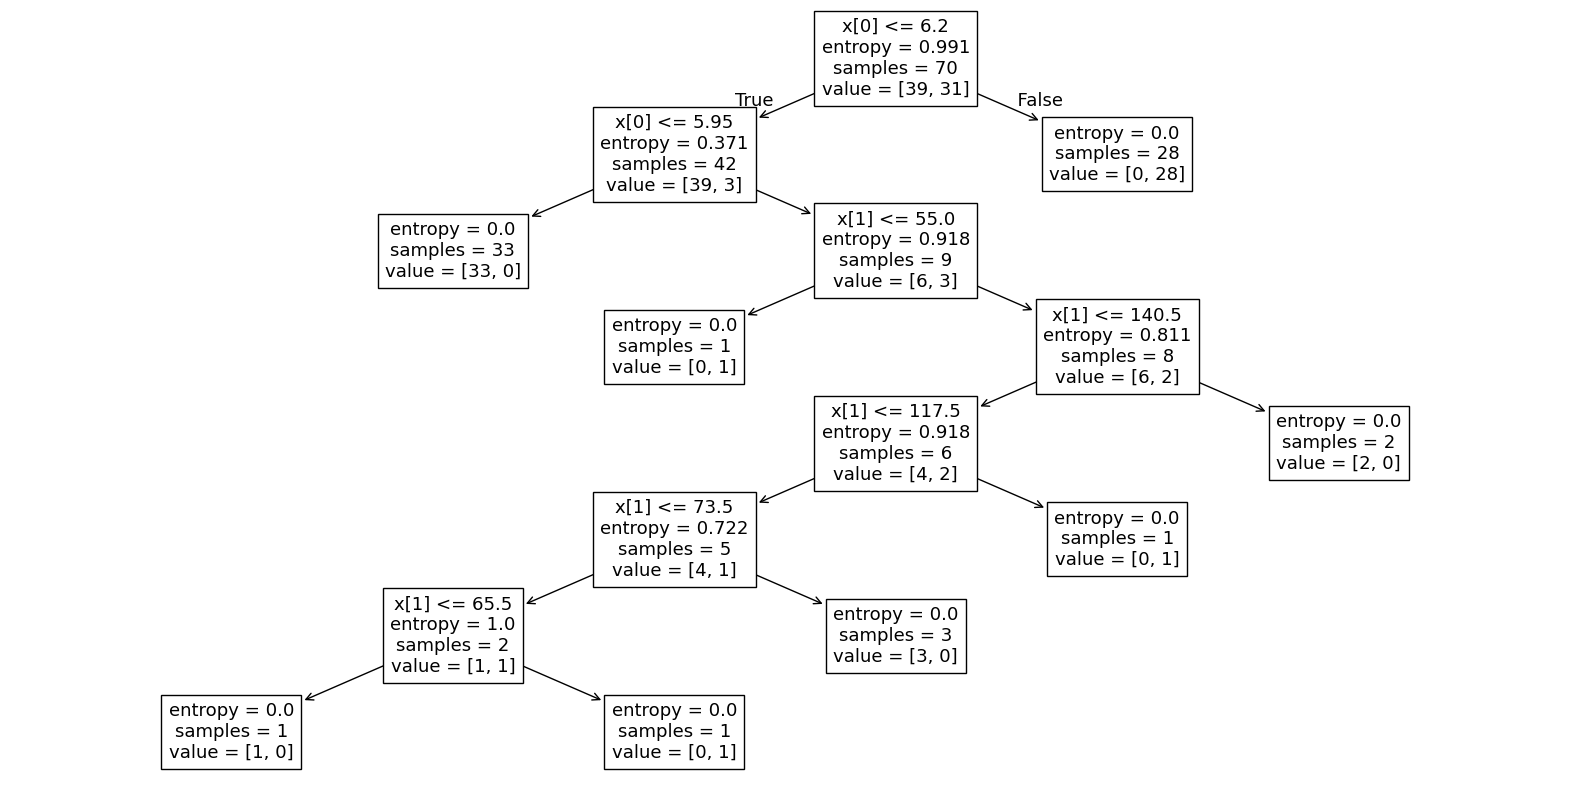

In [40]:
plt.figure(figsize = (20,10))
plot_tree(dts1)
plt.savefig('tree1.jpg')
plt.show()

In [29]:
from mlxtend.plotting import plot_decision_regions

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


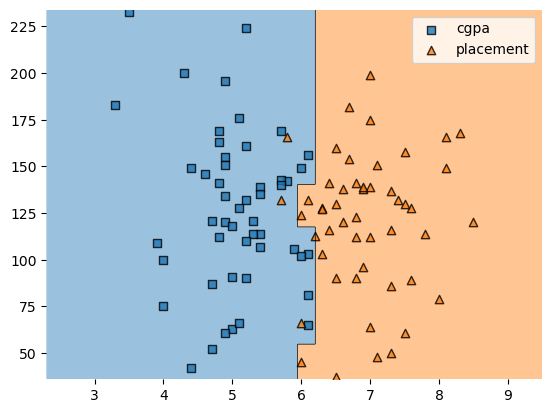

In [43]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf =dts)
plt.legend(['cgpa','placement'])
plt.show()

In [46]:
for i in range(1,20):
    dts2 = DecisionTreeClassifier(criterion = 'entropy')
    dts2.fit(x_train,y_train)
    print(dts2.score(x_train,y_train), dts2.score(x_test,y_test),i)

1.0 0.9 1
1.0 0.9 2
1.0 0.9 3
1.0 0.9 4
1.0 0.9 5
1.0 0.9 6
1.0 0.9 7
1.0 0.9 8
1.0 0.9 9
1.0 0.9 10
1.0 0.9 11
1.0 0.9 12
1.0 0.9 13
1.0 0.9 14
1.0 0.9 15
1.0 0.9 16
1.0 0.9 17
1.0 0.9 18
1.0 0.9 19


In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [36]:
kn = pd.read_csv('placement (2).csv')

In [37]:
kn.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [38]:
kn.isnull().sum()

Unnamed: 0    0
cgpa          0
iq            0
placement     0
dtype: int64

In [40]:
kn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [41]:
kn.drop(['Unnamed: 0'], axis = 1, inplace = True)

In [42]:
x = kn.iloc[:, :-1]
y = kn.iloc[:, -1]

In [43]:
scaler = StandardScaler()
scaler.fit(x)

,copy,True
,with_mean,True
,with_std,True


In [44]:
x = pd.DataFrame(scaler.transform(x), columns = x.columns)

In [45]:
x

,cgpa,iq
0,0.710958,-0.014593
1,-0.079972,-0.442331
2,-0.607258,-0.064915
3,1.238245,0.211856
4,-0.167853,0.463466
...,...,...
95,-1.486069,1.922807
96,-1.398188,-2.052638
97,0.623077,1.469908
98,0.271553,-0.517814


In [46]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size =0.2, random_state = 39)

In [47]:
knc = KNeighborsClassifier(n_neighbors=5)
knc.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [48]:
knc.score(x_test, y_test)*100

90.0

In [49]:
knc.score(x_train, y_train)*100

97.5

In [52]:
y_pred = confusion_matrix(y_test,knc.predict(x_test))

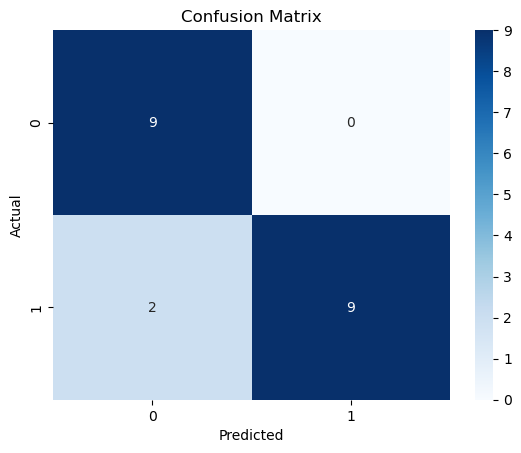

In [53]:
from sklearn.metrics import confusion_matrix
sns.heatmap(y_pred, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [54]:
#It is use to check underfit or Overfit
for i in range(1,20):
    knc1 = KNeighborsClassifier(n_neighbors=5)
    knc1.fit(x_train, y_train)
    print(knc.score(x_test, y_test)*100,knc.score(x_train, y_train)*100,i)

90.0 97.5 1
90.0 97.5 2
90.0 97.5 3
90.0 97.5 4
90.0 97.5 5
90.0 97.5 6
90.0 97.5 7
90.0 97.5 8
90.0 97.5 9
90.0 97.5 10
90.0 97.5 11
90.0 97.5 12
90.0 97.5 13
90.0 97.5 14
90.0 97.5 15
90.0 97.5 16
90.0 97.5 17
90.0 97.5 18
90.0 97.5 19


In [106]:
knc.predict([[0.710958,-0.014593]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

In [108]:
knc.predict([[-0.079972,-0.442331]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


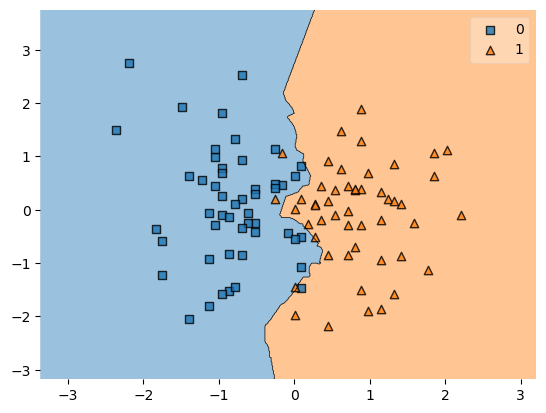

In [55]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf =knc)
plt.show()

In [65]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [77]:
data = pd.read_csv('Iris.csv')
data.head(2)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa


In [67]:
data.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [68]:
x = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [69]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 39)

In [70]:
s =SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
s.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [71]:
s.score(x_test,y_test)*100

97.77777777777777

In [72]:
s.predict([[2,4.9,3.0,1.4,0.2]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array(['Iris-setosa'], dtype=object)

In [82]:
#from mlxtend.plotting import plot_decision_regions
#plot_decision_regions(x.to_numpy(),y.to_numpy(),clf =s)
#plt.show()

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

In [2]:
data = pd.read_csv('nonlinear_data_circles.csv')

In [3]:
data.head()

,x1,x2,label
0,0.160594,0.482602,1
1,1.198440,-0.542104,0
2,-0.618907,0.728517,0
3,1.070839,-0.340617,0
4,0.843196,-0.502865,0


In [4]:
x = data.iloc[:, :-1]
y = data['label']

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 39)

In [6]:
s =SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
s.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [7]:
s.score(x_test,y_test)*100

99.8

In [8]:
s.predict([[1.198440,-0.542104]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([0])

In [9]:
s.predict([[0.160594,0.482602]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([1])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


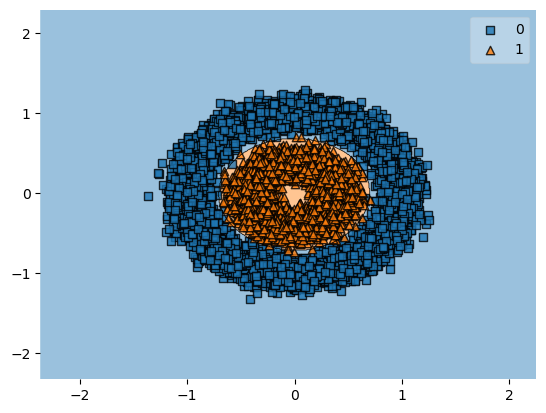

In [10]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf =s)
plt.show()

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
data = pd.read_csv('placement .csv')

In [13]:
data.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [14]:
x = data.iloc[:, :-1]
y = data['package']

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 39)

In [16]:
from sklearn.tree import DecisionTreeRegressor

In [40]:
dtr = DecisionTreeRegressor(criterion='squared_error', max_depth= 3, splitter= 'best')
dtr.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [20]:
dtr.score(x_train,y_train)*100

95.80102919266439

In [41]:
dtr.score(x_test,y_test)*100

67.08735208344854

In [22]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [29]:
df = { 'criterion':['squared_error','friedman__mse','absolute_error','poisson'],
      'splitter':['best','random'],
      'max_depth': [i for i in range(3,20)]}

In [30]:
gd = GridSearchCV(DecisionTreeRegressor(),param_grid = df, cv = 5)
gd.fit(x_train,y_train)

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
170 fits failed out of a total of 680.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
170 fits failed with the following error:
Traceback (most recent call last):
  File "/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
  File "/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "/home/hp/anaconda3/l

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman__mse', ...], 'max_depth': [3, 4, ...], 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [31]:
gd.best_params_

{'criterion': 'squared_error', 'max_depth': 3, 'splitter': 'best'}

In [28]:
gd.score(x_test,y_test)*100

67.08735208344854

In [52]:
rd = RandomizedSearchCV(DecisionTreeRegressor(),param_distributions = df, n_iter = 20)
rd.fit(x_train,y_train)

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
  File "/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "/home/hp/anaconda3/lib

,estimator,DecisionTreeRegressor()
,param_distributions,"{'criterion': ['squared_error', 'friedman__mse', ...], 'max_depth': [3, 4, ...], 'splitter': ['best', 'random']}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [53]:
rd.best_params_

{'splitter': 'best', 'max_depth': 3, 'criterion': 'squared_error'}

In [54]:
rd.score(x_test,y_test)*100

67.08735208344854

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('placement .csv')

In [16]:
data.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [18]:
x = data.iloc[:, :-1]
y = data['package']

In [19]:
from sklearn.linear_model import LinearRegression

In [21]:
from sklearn.model_selection import cross_val_score

In [34]:
p = cross_val_score(LinearRegression(),x,y, cv = KFold(n_splits = 30))

In [35]:
p.sort()
p

array([0.05713994, 0.1280248 , 0.3866331 , 0.43962218, 0.45869581,
       0.49117604, 0.50442232, 0.5863192 , 0.60466612, 0.61403499,
       0.62058619, 0.62185487, 0.62504284, 0.63374731, 0.64924595,
       0.68127219, 0.68344535, 0.72129875, 0.75445473, 0.78183788,
       0.78911776, 0.80509684, 0.82370913, 0.83661656, 0.84296096,
       0.84298076, 0.84755639, 0.85197818, 0.85754797, 0.93834555])

In [4]:
new_data = data.head(10)

In [5]:
new_data.head(10)

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
5,7.89,2.99
6,6.73,2.60
7,6.75,2.48
8,6.09,2.31
9,8.31,3.51


In [6]:
x_new = new_data.iloc[:, :-1]
y_new = new_data['package']

In [7]:
from sklearn.model_selection import LeaveOneOut, LeavePOut, KFold, StratifiedKFold

In [10]:
loo =  LeaveOneOut()

In [9]:
for train, test in loo.split(x_new, y_new):
    print(train,test)

[1 2 3 4 5 6 7 8 9] [0]
[0 2 3 4 5 6 7 8 9] [1]
[0 1 3 4 5 6 7 8 9] [2]
[0 1 2 4 5 6 7 8 9] [3]
[0 1 2 3 5 6 7 8 9] [4]
[0 1 2 3 4 6 7 8 9] [5]
[0 1 2 3 4 5 7 8 9] [6]
[0 1 2 3 4 5 6 8 9] [7]
[0 1 2 3 4 5 6 7 9] [8]
[0 1 2 3 4 5 6 7 8] [9]


In [13]:
lpo = LeavePOut(p = 2)
for train, test in lpo.split(x_new, y_new):
    print(train,test)

[2 3 4 5 6 7 8 9] [0 1]
[1 3 4 5 6 7 8 9] [0 2]
[1 2 4 5 6 7 8 9] [0 3]
[1 2 3 5 6 7 8 9] [0 4]
[1 2 3 4 6 7 8 9] [0 5]
[1 2 3 4 5 7 8 9] [0 6]
[1 2 3 4 5 6 8 9] [0 7]
[1 2 3 4 5 6 7 9] [0 8]
[1 2 3 4 5 6 7 8] [0 9]
[0 3 4 5 6 7 8 9] [1 2]
[0 2 4 5 6 7 8 9] [1 3]
[0 2 3 5 6 7 8 9] [1 4]
[0 2 3 4 6 7 8 9] [1 5]
[0 2 3 4 5 7 8 9] [1 6]
[0 2 3 4 5 6 8 9] [1 7]
[0 2 3 4 5 6 7 9] [1 8]
[0 2 3 4 5 6 7 8] [1 9]
[0 1 4 5 6 7 8 9] [2 3]
[0 1 3 5 6 7 8 9] [2 4]
[0 1 3 4 6 7 8 9] [2 5]
[0 1 3 4 5 7 8 9] [2 6]
[0 1 3 4 5 6 8 9] [2 7]
[0 1 3 4 5 6 7 9] [2 8]
[0 1 3 4 5 6 7 8] [2 9]
[0 1 2 5 6 7 8 9] [3 4]
[0 1 2 4 6 7 8 9] [3 5]
[0 1 2 4 5 7 8 9] [3 6]
[0 1 2 4 5 6 8 9] [3 7]
[0 1 2 4 5 6 7 9] [3 8]
[0 1 2 4 5 6 7 8] [3 9]
[0 1 2 3 6 7 8 9] [4 5]
[0 1 2 3 5 7 8 9] [4 6]
[0 1 2 3 5 6 8 9] [4 7]
[0 1 2 3 5 6 7 9] [4 8]
[0 1 2 3 5 6 7 8] [4 9]
[0 1 2 3 4 7 8 9] [5 6]
[0 1 2 3 4 6 8 9] [5 7]
[0 1 2 3 4 6 7 9] [5 8]
[0 1 2 3 4 6 7 8] [5 9]
[0 1 2 3 4 5 8 9] [6 7]
[0 1 2 3 4 5 7 9] [6 8]
[0 1 2 3 4 5 7 8

In [15]:
kf = KFold(n_splits = 4)
for train, test in kf.split(x_new, y_new):
    print(train,test)

[3 4 5 6 7 8 9] [0 1 2]
[0 1 2 6 7 8 9] [3 4 5]
[0 1 2 3 4 5 8 9] [6 7]
[0 1 2 3 4 5 6 7] [8 9]
